In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [132]:
data = pd.read_csv('card_transdata.csv')
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [133]:
data.shape

(1000000, 8)

In [134]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [135]:
data.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [136]:
data.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [137]:
data.duplicated().sum()

np.int64(0)

In [138]:
print('-----------------count-----------------')
print(data['fraud'].value_counts())
print('-----------------percentage-----------------')
print(data['fraud'].value_counts(normalize=True)*100)


-----------------count-----------------
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64
-----------------percentage-----------------
fraud
0.0    91.2597
1.0     8.7403
Name: proportion, dtype: float64


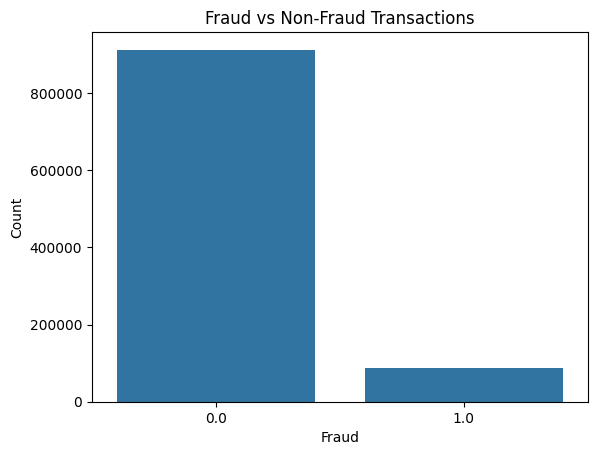

In [139]:
sns.countplot(x='fraud', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

In [140]:
#getting the unique values in coulmns 
for column in data.columns:
    print(f"{column} - {data[column].unique()}")
    # print(f"Unique values in '{column}': {unique_values}")
    print("-" * 40)

distance_from_home - [57.87785658 10.8299427   5.09107949 ...  2.91485699  4.25872939
 58.10812496]
----------------------------------------
distance_from_last_transaction - [0.31114001 0.1755915  0.80515259 ... 1.47268669 0.24202337 0.31811012]
----------------------------------------
ratio_to_median_purchase_price - [1.94593998 1.29421881 0.42771456 ... 0.21807549 0.47582206 0.38691985]
----------------------------------------
repeat_retailer - [1. 0.]
----------------------------------------
used_chip - [1. 0.]
----------------------------------------
used_pin_number - [0. 1.]
----------------------------------------
online_order - [0. 1.]
----------------------------------------
fraud - [0. 1.]
----------------------------------------


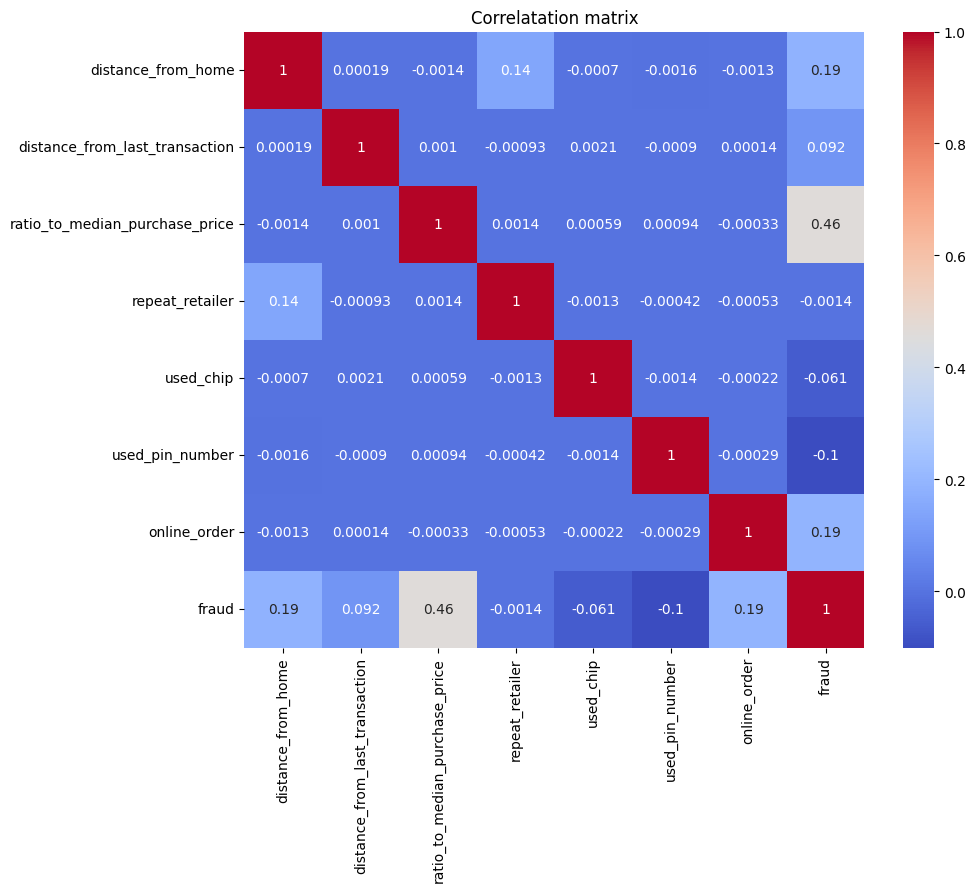

In [141]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("Correlatation matrix")
plt.show()

In [142]:
fraud = data[data['fraud'] == 1]
non_fraud = data[data['fraud'] == 0]

print("Fraud Transactions:", len(fraud))
print("Non-Fraud Transactions:", len(non_fraud))

Fraud Transactions: 87403
Non-Fraud Transactions: 912597


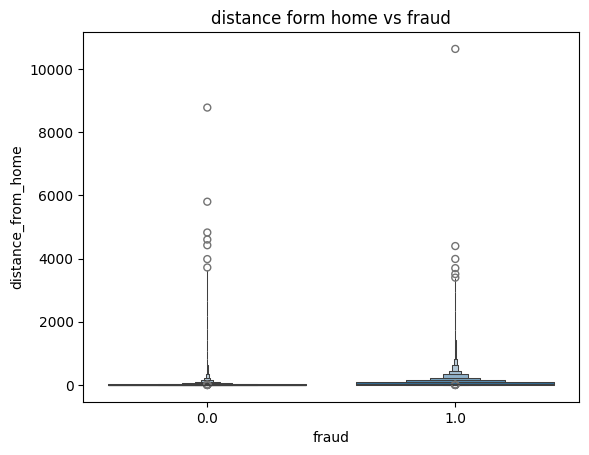

In [143]:
plt.Figure(figsize=(10,8))
sns.boxenplot(x='fraud', y='distance_from_home', data=data)
plt.title("distance form home vs fraud")
plt.show()


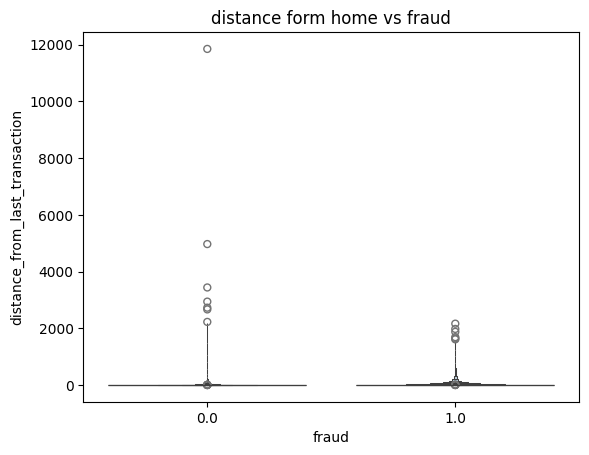

In [144]:
plt.Figure(figsize=(10,8))
sns.boxenplot(x='fraud', y='distance_from_last_transaction', data=data)
plt.title("distance form home vs fraud")
plt.show()

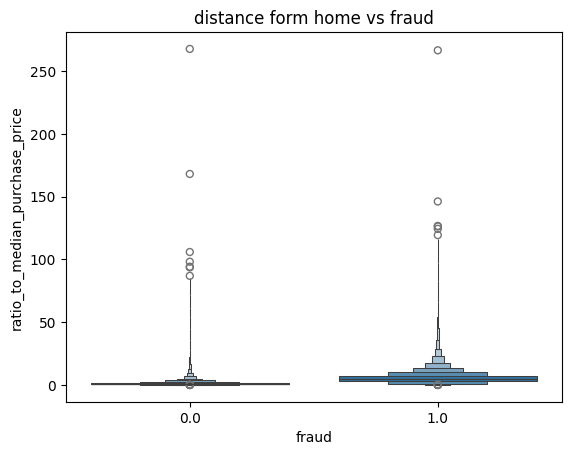

In [145]:
plt.Figure(figsize=(10,8))
sns.boxenplot(x='fraud', y='ratio_to_median_purchase_price', data=data)
plt.title("distance form home vs fraud")
plt.show()

In [146]:
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


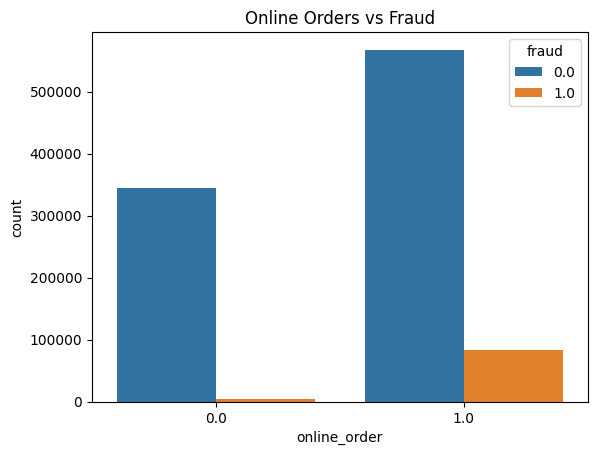

In [147]:
sns.countplot(x='online_order', hue='fraud', data=data)
plt.title("Online Orders vs Fraud")
plt.show()

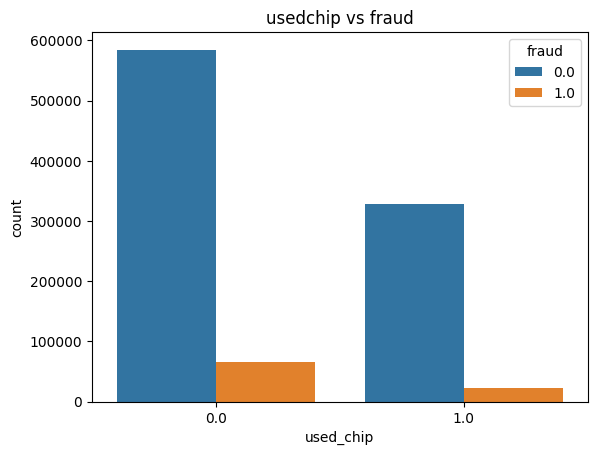

In [148]:
sns.countplot(x='used_chip', hue='fraud', data= data)
plt.title('usedchip vs fraud')
plt.show()

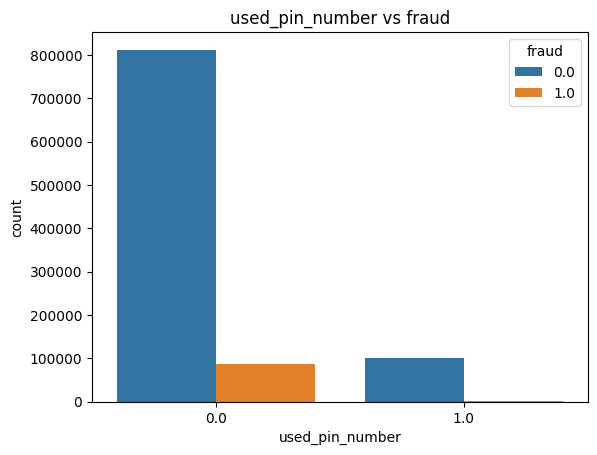

In [149]:
sns.countplot(x='used_pin_number', hue='fraud',data = data)
plt.title('used_pin_number vs fraud')
plt.show()

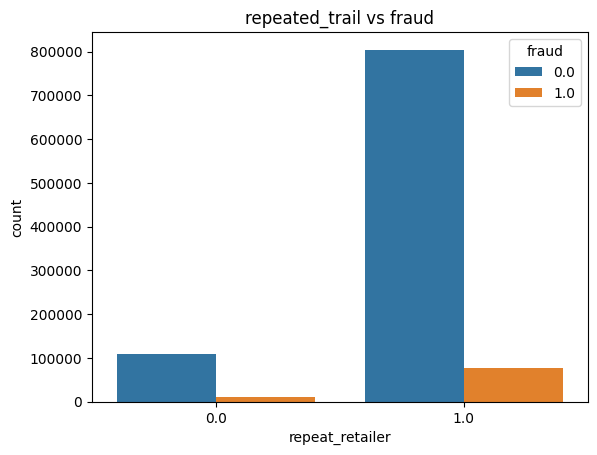

In [150]:
sns.countplot(x='repeat_retailer', hue='fraud', data=data)
plt.title('repeated_trail vs fraud')
plt.show()

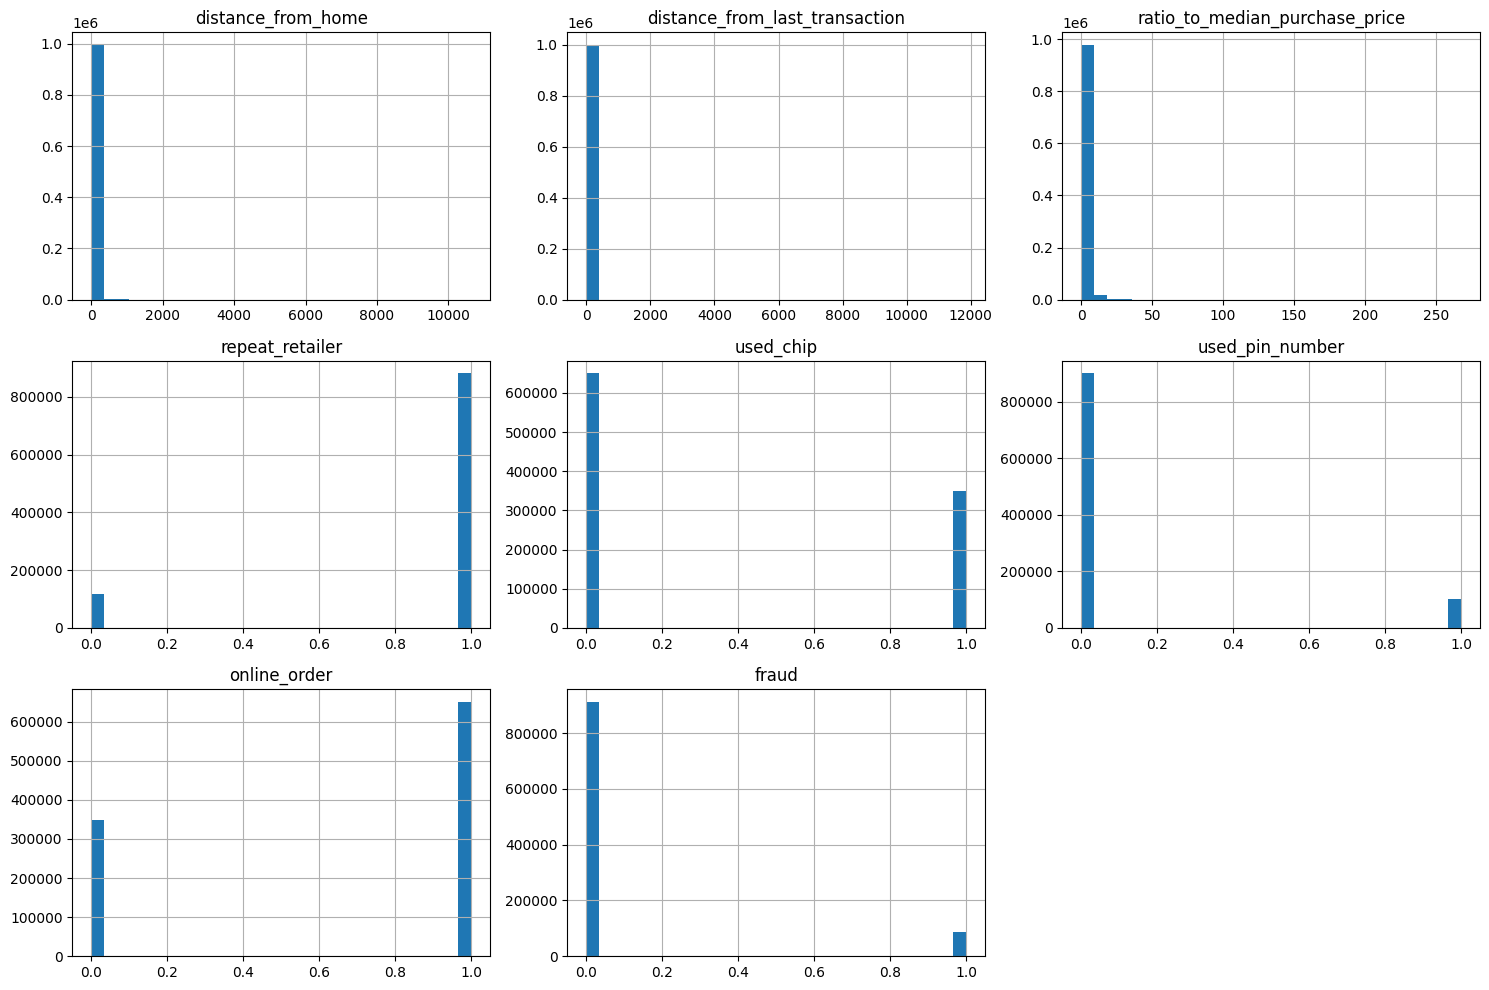

In [151]:
data.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

In [152]:
data.columns

Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order', 'fraud'],
      dtype='str')

In [153]:
#calculating the fraud percentage  by fetures 
pd.crosstab(data['online_order'],data['fraud'],normalize='index')*100


fraud,0.0,1.0
online_order,,
0.0,98.657311,1.342689
1.0,87.286028,12.713972


In [154]:
pd.crosstab(data['used_pin_number'],data['fraud'],normalize='index')*100

fraud,0.0,1.0
used_pin_number,,
0.0,90.312344,9.687656
1.0,99.728650,0.271350


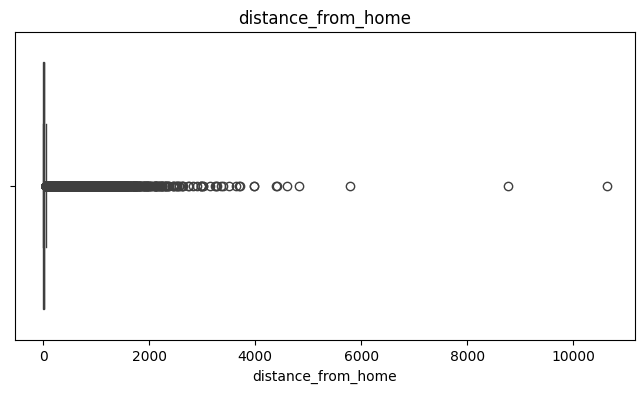

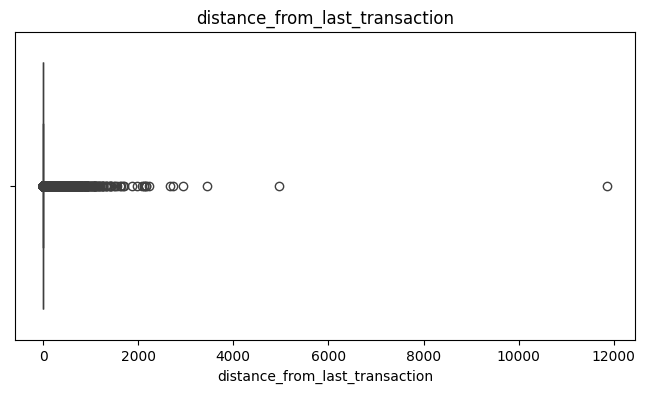

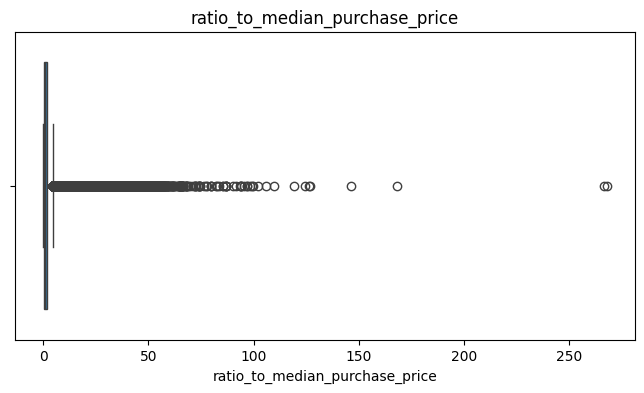

In [155]:
numerical_cols = [
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price'
]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [156]:
x = data.drop('fraud', axis=1)
y = data['fraud']

In [157]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [158]:
numerical_cols = [
    'distance_from_home',
    'distance_from_last_transaction',
    'ratio_to_median_purchase_price'
]

In [159]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])


In [160]:
y_train.value_counts()

fraud
0.0    730040
1.0     69960
Name: count, dtype: int64

In [161]:
y_train.value_counts(normalize=True)*100

fraud
0.0    91.255
1.0     8.745
Name: proportion, dtype: float64

In [162]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [163]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train,y_train)

In [164]:
y_train_smote.value_counts(normalize=True)*100


fraud
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

In [165]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [166]:
#logitic regrssion is osed because 
#1. we have the 0 and 1 to predict that is fraud or geniun (predict probability)
#2. it is fast and used in many industries 
#3. work for binary classification.
lr_model = LogisticRegression()
lr_model.fit(x_train_smote,y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [167]:
pred_lr = lr_model.predict(x_test)

In [168]:
pred_lr

array([0., 1., 0., ..., 1., 0., 0.], shape=(200000,))

In [169]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_smote,y_train_smote)

dt_pred = dt_model.predict(x_test)
dt_pred

array([0., 0., 0., ..., 1., 0., 0.], shape=(200000,))

In [170]:
#Random focasting combines mny decision trees.
# final desision  = voting among the trees.
# more robust
# better generalization
# high fraud detection performance

rf_model = RandomForestClassifier(n_estimators=100 ,random_state=42)
rf_model.fit(x_train_smote,y_train_smote)
rf_predict = rf_model.predict(x_test)
rf_predict

array([0., 0., 0., ..., 1., 0., 0.], shape=(200000,))

In [171]:
rf_probs = rf_model.predict_proba(x_test)
rf_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [1., 0.],
       [1., 0.]], shape=(200000, 2))

In [172]:
rf_fraud_prob = rf_probs[:, 1]

In [173]:
importance  = rf_model.feature_importances_

feture_importance = pd.DataFrame({
    'feature':x.columns,
    'importance':importance
})
feture_importance = feture_importance.sort_values(by='importance', ascending=False)
feture_importance

,feature,importance
2,ratio_to_median_purchase_price,0.551347
0,distance_from_home,0.188003
6,online_order,0.112551
1,distance_from_last_transaction,0.082822
5,used_pin_number,0.032198
4,used_chip,0.025043
3,repeat_retailer,0.008035


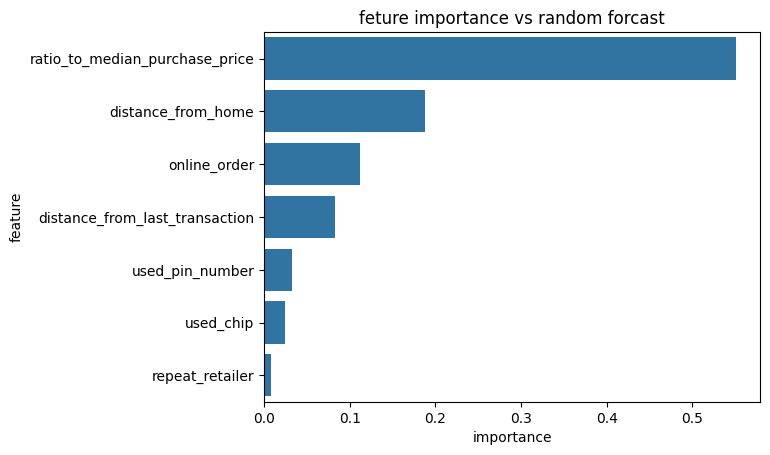

In [174]:
plt.Figure(figsize=(10,8))
sns.barplot(x='importance',y='feature',data = feture_importance)
plt.title('feture importance vs random forcast')
plt.show()

In [175]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [176]:
print("Accuracy score:-",accuracy_score(y_test,pred_lr))
print("precision score",precision_score(y_test,pred_lr))

Accuracy score:- 0.93472
precision score 0.5761499739628537


In [177]:
print("recall score ",recall_score(y_test,pred_lr))

recall score  0.9514418391331766


In [178]:
print("f1 score ",f1_score(y_test,pred_lr))

f1 score  0.7176959003632589


In [179]:
print("confusion matrix ",confusion_matrix(y_test,pred_lr))

confusion matrix  [[170348  12209]
 [   847  16596]]


In [180]:
print("classification report ",classification_report(y_test,pred_lr))

classification report                precision    recall  f1-score   support

         0.0       1.00      0.93      0.96    182557
         1.0       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000



In [181]:
print("roc auc score ",roc_auc_score(y_test,pred_lr))

roc auc score  0.9422820484194946


In [182]:
print("roc curve ", roc_curve(y_test,pred_lr))

roc curve  (array([0.        , 0.06687774, 1.        ]), array([0.        , 0.95144184, 1.        ]), array([inf,  1.,  0.]))


In [183]:
cm_lr = confusion_matrix(y_test,pred_lr)
cm_lr

array([[170348,  12209],
       [   847,  16596]])

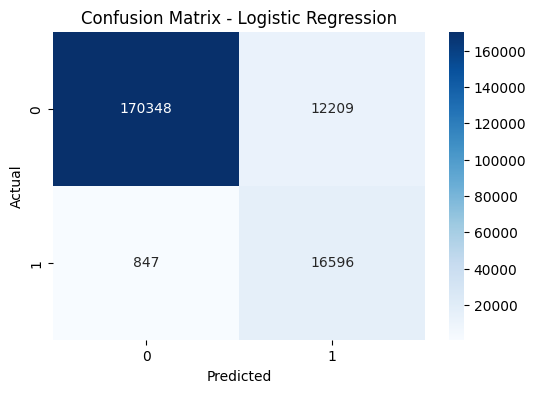

In [184]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [185]:
lr_probs = lr_model.predict_proba(x_test)[:, 1]
roc_auc_score(y_test, lr_probs)

0.9795617529181464

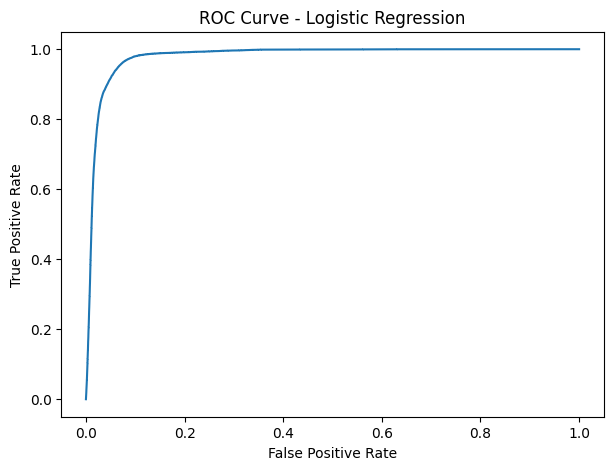

In [186]:
#ROC curve 
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [191]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182557
         1.0       1.00      1.00      1.00     17443

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [192]:
print(classification_report(y_test, rf_predict))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182557
         1.0       1.00      1.00      1.00     17443

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [193]:
#ROC for random forcast
rf_probs = rf_model.predict_proba(x_test)[:, 1]
roc_auc_score(y_test, rf_probs)

0.9999999948183954

In [195]:
# Comparison table for models
models = {
    "LogisticRegression": (pred_lr, lr_probs),
    "DecisionTree": (dt_pred, dt_model.predict_proba(x_test)[:, 1]),
    "RandomForest": (rf_predict, rf_model.predict_proba(x_test)[:, 1]),
}

rows = []
for name, (y_pred, y_prob) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)
    rows.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc
    })

comparison_df = pd.DataFrame(rows).set_index("model")
comparison_df

,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
LogisticRegression,0.934720,0.576150,0.951442,0.717696,0.979562
DecisionTree,0.999970,0.999771,0.999885,0.999828,0.999932
RandomForest,0.999975,0.999885,0.999828,0.999857,1.000000


In [199]:
#applyting the threshold to random forcast
custom_prob =(rf_probs >= 0.3).astype(int)
custom_prob

array([0, 0, 0, ..., 1, 0, 0], shape=(200000,))